  ApexPlanet Data Analytics Internship
## Task 1: Data Immersion & Wrangling

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Ravali\OneDrive\Desktop\netflix_titles.csv")

In [4]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [14]:
df.shape

(8807, 12)

In [16]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [20]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [22]:
df.duplicated().sum()

0

In [24]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [7]:
df[['director','cast','country']].isnull().sum()

director    2634
cast         825
country      831
dtype: int64

In [9]:
df = df.dropna(subset=['date_added', 'rating', 'duration'])

In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2621
cast             825
country          829
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64

In [13]:
df.to_csv("netflix_cleaned.csv", index=False)

In [15]:
df.shape

(8790, 12)

# Netflix Data Cleaning and Exploratory Analysis

Objective:
To clean, preprocess, and prepare Netflix Movies and TV Shows data by handling missing values, improving data quality, and creating an analysis-ready dataset.

Dataset Information

• Dataset Name: Netflix Movies and TV Shows
• Original Dataset Shape: (8807, 12)
• Final Dataset Shape: (8790, 12)
• Number of Columns: 12
• Purpose: To clean and prepare Netflix data for further analysis and visualization.

Data Dictionary

1. show_id        : Unique identifier for each Netflix title.
2. type           : Indicates whether the content is a Movie or TV Show.
3. title          : Name of the movie or TV show.
4. director       : Director name (Unknown if unavailable).
5. cast           : Cast members (Unknown if unavailable).
6. country        : Country of origin (Unknown if unavailable).
7. date_added     : Date the content was added to Netflix.
8. release_year   : Year in which the content was released.
9. rating         : Content maturity rating (TV-MA, PG, etc.).
10. duration      : Duration in minutes or number of seasons.
11. listed_in     : Genre or category of the content.
12. description   : Brief description of the movie or TV show.

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

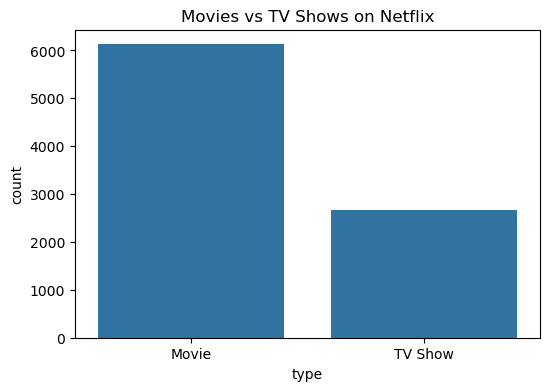

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title('Movies vs TV Shows on Netflix')
plt.show()

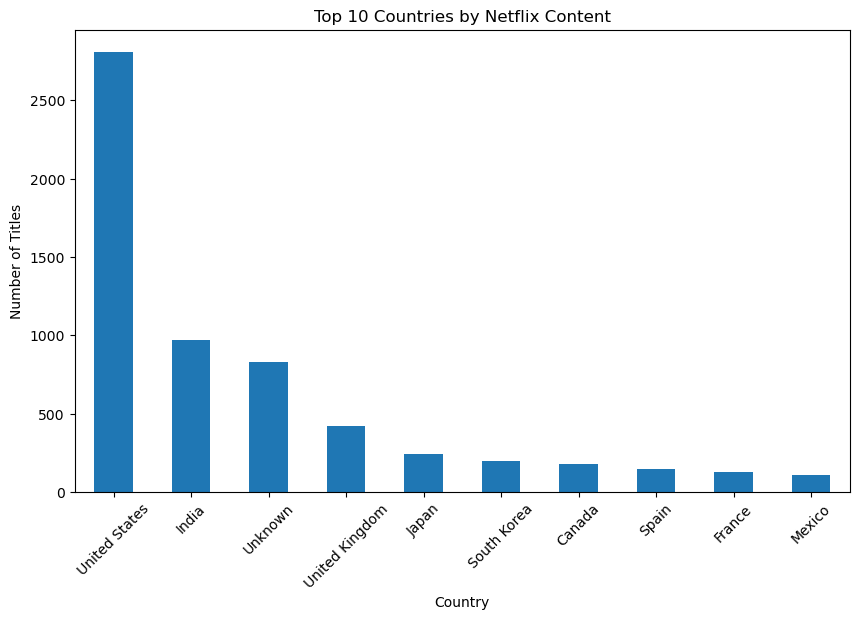

In [40]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

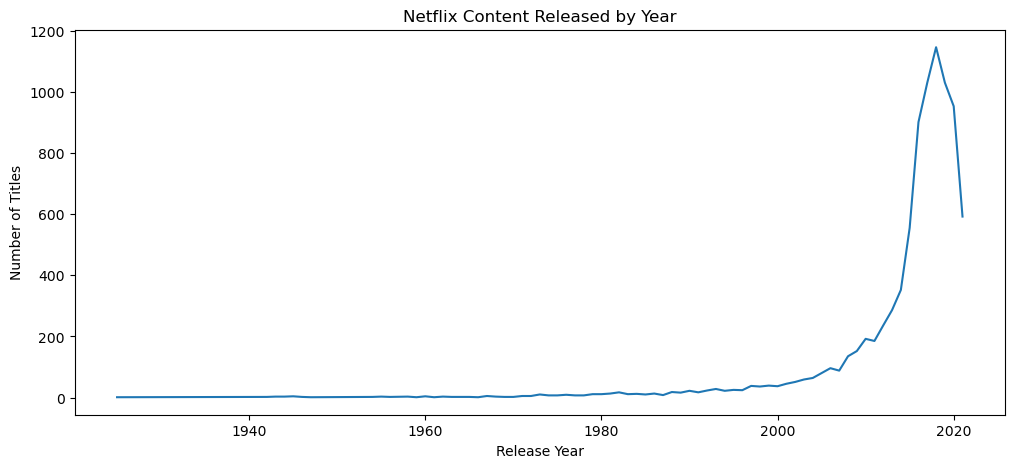

In [42]:
release = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
release.plot(kind='line')
plt.title('Netflix Content Released by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

Project Summary

Project Title:
Netflix Data Cleaning and Exploratory Analysis

Objective:
To clean, preprocess, and prepare Netflix Movies and TV Shows data for analysis.

Tasks Performed:
• Loaded and explored the dataset
• Checked dataset dimensions and columns
• Identified missing values
• Checked duplicate records
• Filled missing values in categorical columns using 'Unknown'
• Removed records with critical missing values
• Saved the cleaned dataset
• Created visualizations for better understanding of the data

Final Dataset Shape:
(8790, 12)

Tools Used:
Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook

# Task 2: Exploratory Data Analysis (EDA) and Business Intelligence

Objective:
To analyze the cleaned Netflix dataset, identify patterns and trends, answer business questions, and derive meaningful insights using statistics and visualizations.

In [48]:
df.shape

(8790, 12)

In [50]:
df.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Observation:
The average release year is around 2014, indicating that Netflix primarily contains modern content. However, the platform also includes older titles dating back to 1925.

Business Insight:
Netflix focuses heavily on recent content while maintaining a library of classic titles to appeal to different audience preferences.

In [53]:
total_titles = len(df)
total_movies = (df['type'] == 'Movie').sum()
total_tv_shows = (df['type'] == 'TV Show').sum()
total_countries = df['country'].nunique()
total_ratings = df['rating'].nunique()

print("Total Titles:", total_titles)
print("Total Movies:", total_movies)
print("Total TV Shows:", total_tv_shows)
print("Total Countries:", total_countries)
print("Total Ratings:", total_ratings)

Total Titles: 8790
Total Movies: 6126
Total TV Shows: 2664
Total Countries: 749
Total Ratings: 14


Observation:
Netflix has 8790 titles, with movies (6126) significantly outnumbering TV shows (2664).

Business Insight:
Netflix's content library is movie-dominant. Expanding TV series production could increase user retention and engagement.

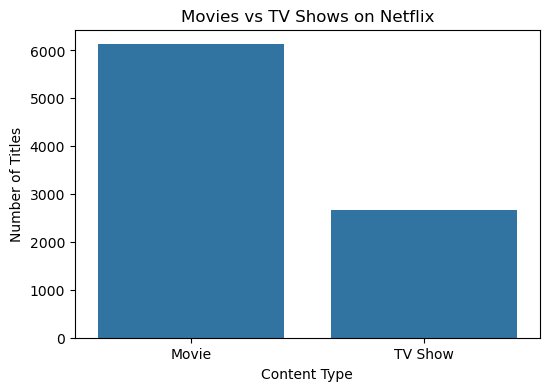

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.show()

Business Question 1:
Are Movies more common than TV Shows on Netflix?

Observation:
Movies (6126) significantly outnumber TV Shows (2664) on Netflix.

Business Insight:
Netflix's content library is movie-dominant. Increasing investment in high-quality TV series could improve subscriber retention and long-term user engagement.

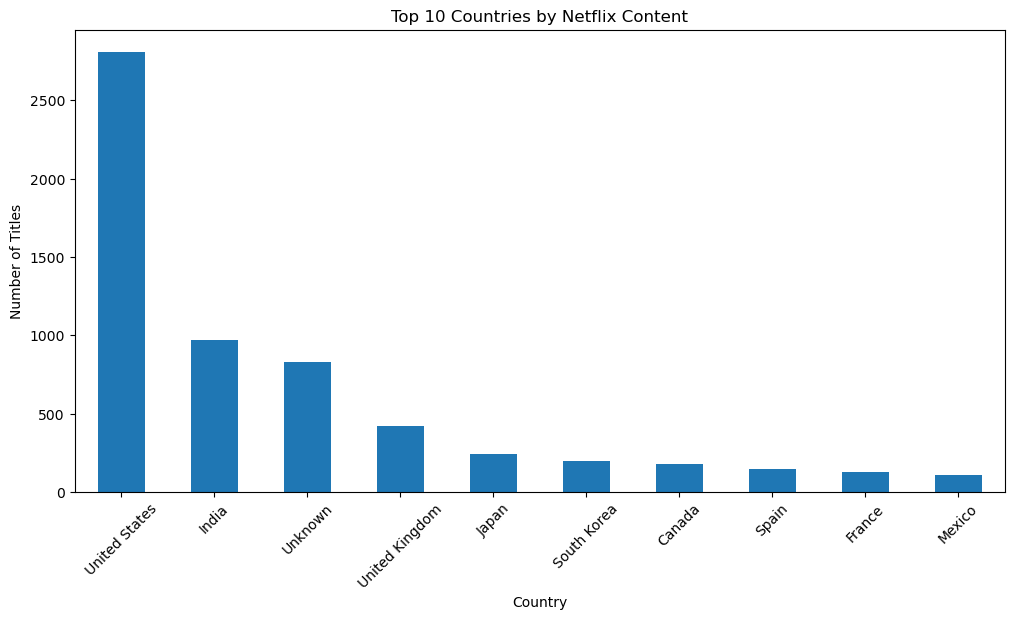

In [59]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

Business Question 2:
Which countries contribute the most content to Netflix?

Observation:
The United States has the highest number of titles on Netflix, followed by other countries such as India and the United Kingdom.

Business Insight:
Netflix relies heavily on content from a few major countries. Increasing investments in other regions can help attract more diverse global audiences and expand market reach.

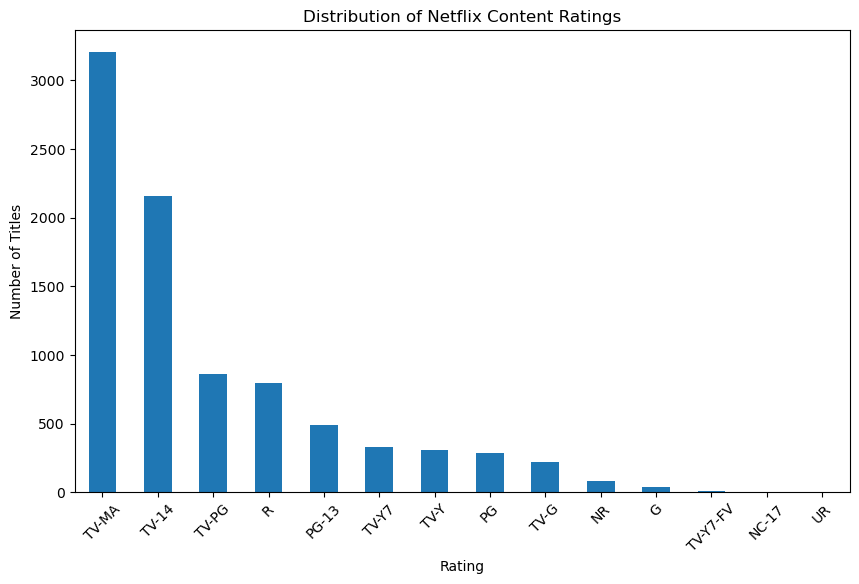

In [62]:
top_ratings = df['rating'].value_counts()

plt.figure(figsize=(10,6))
top_ratings.plot(kind='bar')
plt.title('Distribution of Netflix Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

Business Question 3:
Which content ratings are most common on Netflix?

Observation:
Ratings such as TV-MA and TV-14 appear most frequently in the Netflix dataset.

Business Insight:
Netflix primarily targets teenagers and adult audiences by offering a large amount of mature and teen-oriented content.

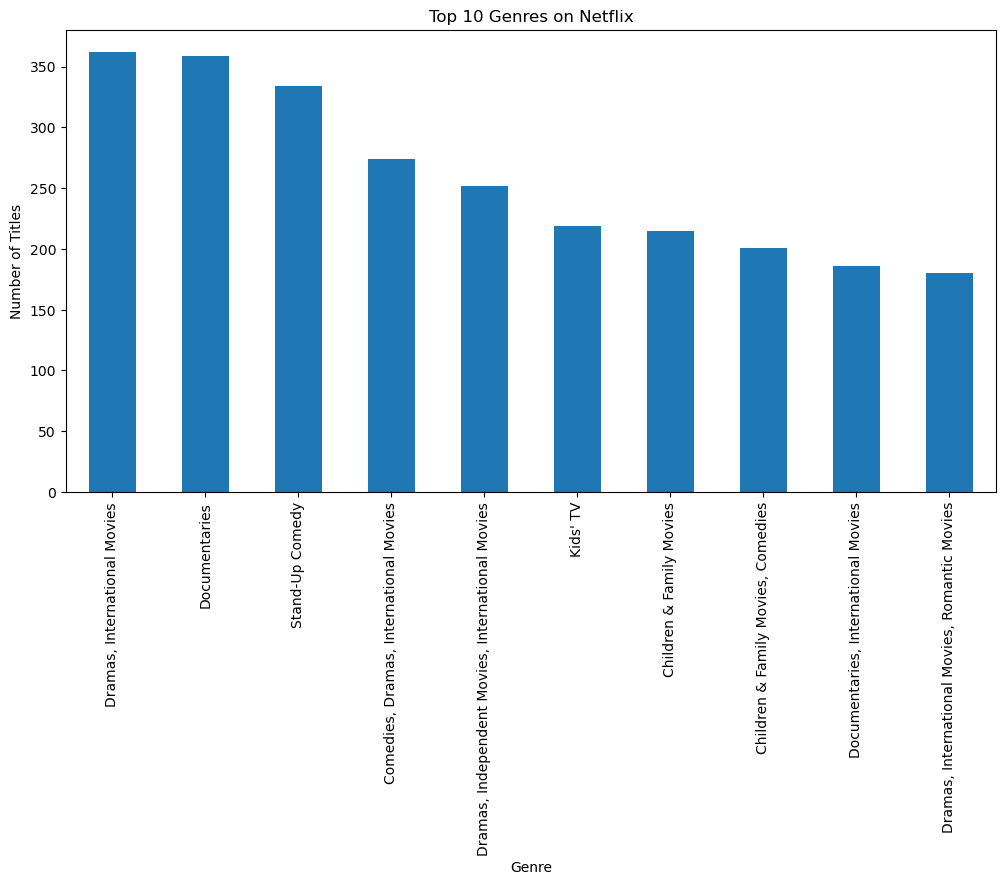

In [65]:
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_genres.plot(kind='bar')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=90)
plt.show()

Business Question 4: Which genres are most popular on Netflix?

Observation: Drama and Documentary-related genres appear most frequently in the Netflix dataset.

Business Insight: Netflix focuses heavily on drama and documentary content, indicating strong audience demand for storytelling and informative entertainment.

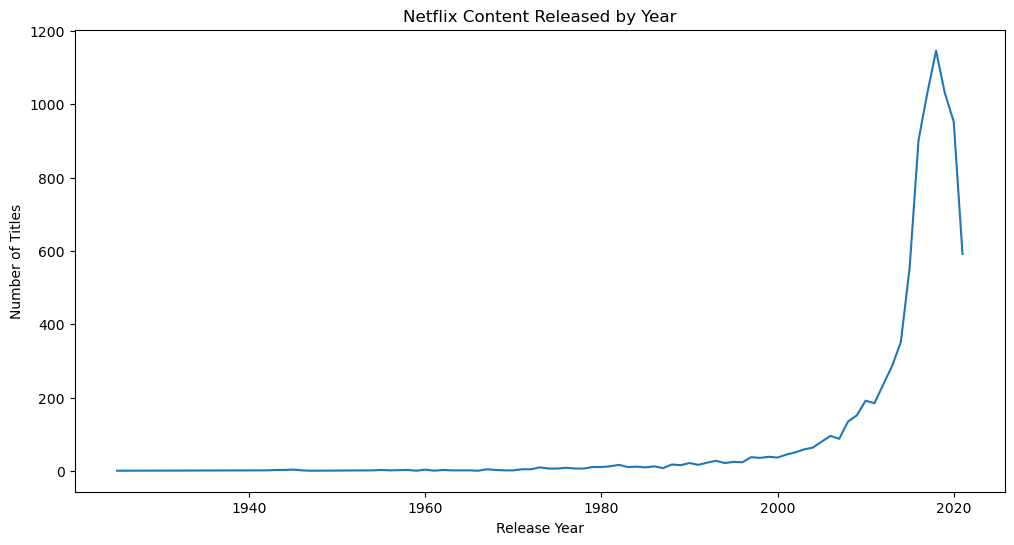

In [67]:
release = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
release.plot(kind='line')
plt.title('Netflix Content Released by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

Business Question 5:
How has Netflix content grown over the years?

Observation:
The number of titles released on Netflix increased significantly after 2015 and reached its peak around recent years.

Business Insight:
Netflix rapidly expanded its content library during the late 2010s, reflecting aggressive investment in content production and acquisition.

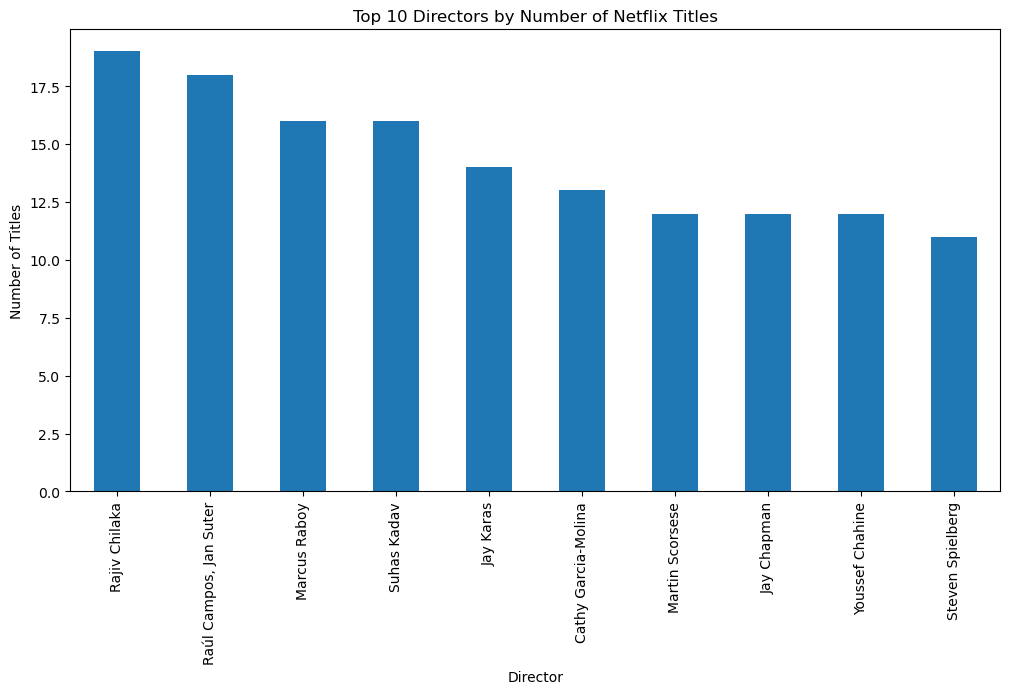

In [70]:
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_directors.plot(kind='bar')
plt.title('Top 10 Directors by Number of Netflix Titles')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.xticks(rotation=90)
plt.show()

Business Question 6:
Which directors have the highest number of titles on Netflix?

Observation:
A few directors have contributed multiple titles to Netflix, while most directors have only a small number of titles.

Business Insight:
Netflix collaborates repeatedly with certain directors, indicating strong partnerships with successful content creators.

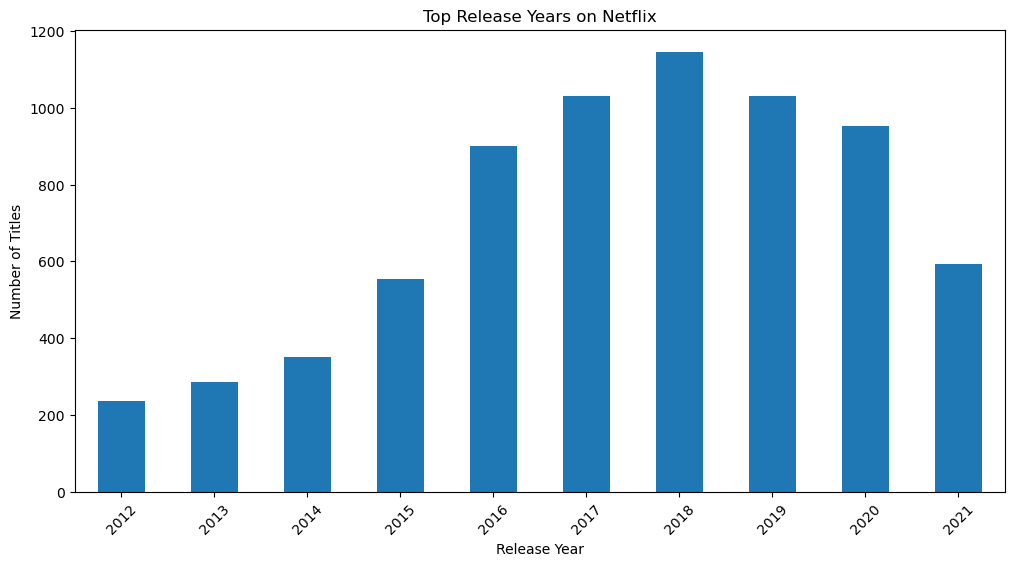

In [73]:
top_years = df['release_year'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_years.sort_index().plot(kind='bar')
plt.title('Top Release Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

Business Question 7:
Which years had the highest number of content releases on Netflix?

Observation:
Netflix content releases increased significantly between 2015 and 2018. The highest number of titles was released in 2018.

Business Insight:
Netflix aggressively expanded its content library during the late 2010s to attract more subscribers and strengthen its global presence.

In [84]:
df = df.copy()

df['title_length'] = df['title'].str.len()
df['description_length'] = df['description'].str.len()

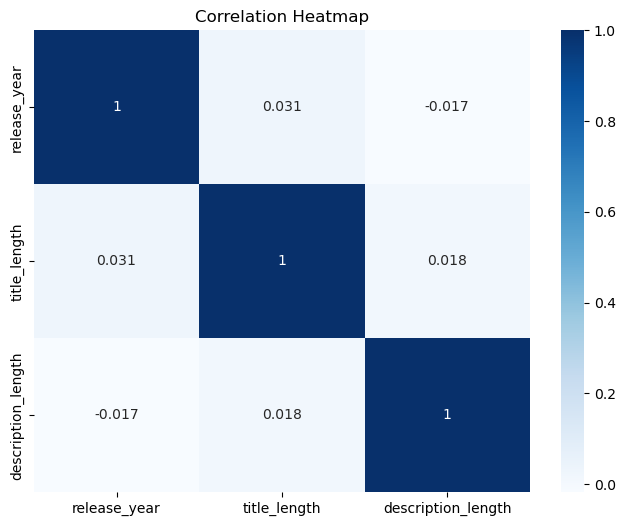

In [86]:
numeric_df = df[['release_year', 'title_length', 'description_length']]

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='Blues')

plt.title('Correlation Heatmap')
plt.show()

Business Question 8: Is there any relationship between release year, title length, and description length?

Observation: The correlation values are very close to zero, indicating that there is no strong relationship among release year, title length, and description length.

Business Insight: Netflix content characteristics such as title names and descriptions appear to be independent of the release year. Therefore, content descriptions and titles are determined by creative choices rather than the release period.

Project Summary

Project Title: Netflix Exploratory Data Analysis (EDA) and Business Intelligence

Objective:
To analyze Netflix Movies and TV Shows data, identify trends and patterns, answer business questions, and derive meaningful insights using statistics and visualizations.

Key Findings:
• Netflix contains 8790 titles.
• Movies significantly outnumber TV Shows.
• The United States contributes the highest amount of content.
• TV-MA and TV-14 are the most common content ratings.
• Drama and Documentary genres dominate the platform.
• Netflix experienced rapid content growth after 2015 and reached its peak around 2018.
• A few directors contribute multiple titles while most directors have fewer titles.
• There is no strong correlation between release year, title length, and description length.

Tools Used:
Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook

# Task 3: Deep-Dive Analysis & Interactive Dashboarding

Objective:
To perform a deeper business analysis on the Netflix dataset, define key performance indicators (KPIs), and create a dashboard that helps users interactively explore business insights.

Deep-Dive Analysis Area:
Netflix Content Distribution and Growth Analysis

Goal:
To understand Netflix's content composition, geographical distribution, genre preferences, and growth trends through KPI metrics and visualizations.

Key Performance Indicators (KPIs)

1. Total Titles
Formula: Total number of records in the dataset.

2. Total Movies
Formula: Count of titles where Type = Movie.

3. Total TV Shows
Formula: Count of titles where Type = TV Show.

4. Total Countries
Formula: Number of unique countries represented in the dataset.

5. Total Ratings
Formula: Number of unique content ratings in the dataset.

In [99]:
print(" Total Titles:", total_titles)
print(" Total Movies:", total_movies)
print(" Total TV Shows:", total_tv_shows)
print(" Total Countries:", total_countries)
print(" Total Ratings:", total_ratings)

 Total Titles: 8790
 Total Movies: 6126
 Total TV Shows: 2664
 Total Countries: 749
 Total Ratings: 14
